In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

import pickle

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../Dataset/HDI.csv")

In [3]:
df.head()

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95


In [4]:
df = pd.read_csv("../Dataset/HDI.csv")

In [5]:
df.head()

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95


In [6]:
df.shape

(195, 880)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Columns: 880 entries, ISO3 to Material footprint per capita (tonnes) (2021)
dtypes: float64(876), object(4)
memory usage: 1.3+ MB


In [8]:
df.describe()

,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),Human Development Index (1995),Human Development Index (1996),Human Development Index (1997),Human Development Index (1998),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
count,191.000000,141.000000,141.000000,141.000000,141.000000,141.000000,152.000000,152.000000,152.000000,152.000000,...,157.00000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,95.811518,0.599277,0.601979,0.604525,0.608504,0.613411,0.617625,0.623336,0.628599,0.634059,...,15.55535,15.675860,15.631146,15.637707,15.637834,15.798089,14.840000,15.019490,15.019490,15.019490
std,55.307333,0.164044,0.164100,0.164457,0.165456,0.166191,0.164990,0.165710,0.166592,0.167486,...,14.49240,14.930422,14.730498,15.063439,15.412834,15.739461,13.932553,14.644025,14.644025,14.644025
min,1.000000,0.216000,0.218000,0.222000,0.227000,0.232000,0.238000,0.243000,0.248000,0.256000,...,0.43000,0.420000,0.450000,0.560000,0.600000,0.610000,0.500000,0.470000,0.470000,0.470000
25%,48.500000,0.482000,0.484000,0.485000,0.485000,0.486000,0.486750,0.490750,0.492000,0.493000,...,4.53000,4.510000,4.350000,4.360000,4.420000,4.560000,4.590000,4.620000,4.620000,4.620000
50%,96.000000,0.628000,0.629000,0.627000,0.634000,0.639000,0.646500,0.653000,0.658000,0.664500,...,10.53000,10.370000,10.680000,10.020000,10.400000,10.740000,11.150000,10.620000,10.620000,10.620000
75%,143.500000,0.728000,0.729000,0.727000,0.731000,0.741000,0.745250,0.752000,0.759250,0.767000,...,20.90000,20.780000,20.750000,21.290000,19.790000,20.030000,18.960000,18.870000,18.870000,18.870000
max,191.000000,0.872000,0.873000,0.878000,0.880000,0.884000,0.885000,0.887000,0.890000,0.895000,...,74.56000,82.970000,81.100000,86.780000,83.510000,88.700000,71.160000,85.700000,85.700000,85.700000


In [9]:
df["Country"].unique()

array(['Afghanistan', 'Angola', 'Albania', 'Andorra',
       'United Arab Emirates', 'Argentina', 'Armenia',
       'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan',
       'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bulgaria', 'Bahrain', 'Bahamas', 'Bosnia and Herzegovina',
       'Belarus', 'Belize', 'Bolivia', 'Brazil', 'Barbados', 'Brunei',
       'Bhutan', 'Botswana', 'Central African Republic', 'Canada',
       'Switzerland', 'Chile', 'China', 'Ivory Coast', 'Cameroon',
       'The Democratic Republic of the Congo', 'Congo', 'Colombia',
       'Comoros', 'Cabo Verde', 'Costa Rica', 'Cuba', 'Cyprus', 'Czechia',
       'Germany', 'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic',
       'Algeria', 'Ecuador', 'Egypt', 'Eritrea', 'Spain', 'Estonia',
       'Ethiopia', 'Finland', 'Fiji', 'France', 'Micronesia', 'Gabon',
       'United Kingdom', 'Georgia', 'Ghana', 'Guinea', 'Gambia',
       'Guinea-Bissau', 'Equatorial Guinea', 'Greece', 'Gren

In [10]:
df["Country"].unique()

array(['Afghanistan', 'Angola', 'Albania', 'Andorra',
       'United Arab Emirates', 'Argentina', 'Armenia',
       'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan',
       'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bulgaria', 'Bahrain', 'Bahamas', 'Bosnia and Herzegovina',
       'Belarus', 'Belize', 'Bolivia', 'Brazil', 'Barbados', 'Brunei',
       'Bhutan', 'Botswana', 'Central African Republic', 'Canada',
       'Switzerland', 'Chile', 'China', 'Ivory Coast', 'Cameroon',
       'The Democratic Republic of the Congo', 'Congo', 'Colombia',
       'Comoros', 'Cabo Verde', 'Costa Rica', 'Cuba', 'Cyprus', 'Czechia',
       'Germany', 'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic',
       'Algeria', 'Ecuador', 'Egypt', 'Eritrea', 'Spain', 'Estonia',
       'Ethiopia', 'Finland', 'Fiji', 'France', 'Micronesia', 'Gabon',
       'United Kingdom', 'Georgia', 'Ghana', 'Guinea', 'Gambia',
       'Guinea-Bissau', 'Equatorial Guinea', 'Greece', 'Gren

In [11]:
data1 = df.head(20)

In [12]:
data1

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95
5,ARG,Argentina,Very High,LAC,47.0,0.723,0.730,0.735,0.739,0.744,...,15.69,16.74,16.57,17.85,16.95,18.75,16.88,15.81,15.81,15.81
6,ARM,Armenia,High,ECA,85.0,0.656,0.649,0.618,0.616,0.620,...,6.27,6.15,6.44,6.50,7.79,7.35,6.01,5.95,5.95,5.95
7,ATG,Antigua and Barbuda,High,LAC,71.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AUS,Australia,Very High,NaN,5.0,0.865,0.867,0.869,0.873,0.873,...,49.09,45.97,47.80,46.91,46.32,48.27,47.70,46.82,46.82,46.82
9,AUT,Austria,Very High,NaN,25.0,0.825,0.829,0.835,0.840,0.845,...,27.26,27.32,27.48,26.40,26.89,25.62,25.39,24.62,24.62,24.62


In [13]:
df.columns

Index(['ISO3', 'Country', 'Human Development Groups',
       'UNDP Developing Regions', 'HDI Rank (2021)',
       'Human Development Index (1990)', 'Human Development Index (1991)',
       'Human Development Index (1992)', 'Human Development Index (1993)',
       'Human Development Index (1994)',
       ...
       'Material footprint per capita (tonnes) (2012)',
       'Material footprint per capita (tonnes) (2013)',
       'Material footprint per capita (tonnes) (2014)',
       'Material footprint per capita (tonnes) (2015)',
       'Material footprint per capita (tonnes) (2016)',
       'Material footprint per capita (tonnes) (2017)',
       'Material footprint per capita (tonnes) (2018)',
       'Material footprint per capita (tonnes) (2019)',
       'Material footprint per capita (tonnes) (2020)',
       'Material footprint per capita (tonnes) (2021)'],
      dtype='object', length=880)

In [14]:
list(df.columns)

['ISO3',
 'Country',
 'Human Development Groups',
 'UNDP Developing Regions',
 'HDI Rank (2021)',
 'Human Development Index (1990)',
 'Human Development Index (1991)',
 'Human Development Index (1992)',
 'Human Development Index (1993)',
 'Human Development Index (1994)',
 'Human Development Index (1995)',
 'Human Development Index (1996)',
 'Human Development Index (1997)',
 'Human Development Index (1998)',
 'Human Development Index (1999)',
 'Human Development Index (2000)',
 'Human Development Index (2001)',
 'Human Development Index (2002)',
 'Human Development Index (2003)',
 'Human Development Index (2004)',
 'Human Development Index (2005)',
 'Human Development Index (2006)',
 'Human Development Index (2007)',
 'Human Development Index (2008)',
 'Human Development Index (2009)',
 'Human Development Index (2010)',
 'Human Development Index (2011)',
 'Human Development Index (2012)',
 'Human Development Index (2013)',
 'Human Development Index (2014)',
 'Human Development Index (

In [15]:
list(df.columns)

['ISO3',
 'Country',
 'Human Development Groups',
 'UNDP Developing Regions',
 'HDI Rank (2021)',
 'Human Development Index (1990)',
 'Human Development Index (1991)',
 'Human Development Index (1992)',
 'Human Development Index (1993)',
 'Human Development Index (1994)',
 'Human Development Index (1995)',
 'Human Development Index (1996)',
 'Human Development Index (1997)',
 'Human Development Index (1998)',
 'Human Development Index (1999)',
 'Human Development Index (2000)',
 'Human Development Index (2001)',
 'Human Development Index (2002)',
 'Human Development Index (2003)',
 'Human Development Index (2004)',
 'Human Development Index (2005)',
 'Human Development Index (2006)',
 'Human Development Index (2007)',
 'Human Development Index (2008)',
 'Human Development Index (2009)',
 'Human Development Index (2010)',
 'Human Development Index (2011)',
 'Human Development Index (2012)',
 'Human Development Index (2013)',
 'Human Development Index (2014)',
 'Human Development Index (

In [16]:
data1.head()

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95


In [17]:
for col in df.columns:
    if "2021" in col:
        print(col)

HDI Rank (2021)
Human Development Index (2021)
Life Expectancy at Birth (2021)
Expected Years of Schooling (2021)
Mean Years of Schooling (2021)
Gross National Income Per Capita (2021)
GDI Group (2021)
Gender Development Index (2021)
HDI female (2021)
Life Expectancy at Birth, female (2021)
Expected Years of Schooling, female (2021)
Mean Years of Schooling, female (2021)
Gross National Income Per Capita, female (2021)
HDI male (2021)
Life Expectancy at Birth, male (2021)
Expected Years of Schooling, male (2021)
Mean Years of Schooling, male (2021)
Gross National Income Per Capita, male (2021)
Inequality-adjusted Human Development Index (2021)
Coefficient of human inequality (2021)
Overall loss (%) (2021)
Inequality in life expectancy (2021)
Inequality in eduation (2021)
Inequality in income (2021)
GII Rank (2021)
Gender Inequality Index (2021)
Maternal Mortality Ratio (deaths per 100,000 live births) (2021)
Adolescent Birth Rate (births per 1,000 women ages 15-19) (2021)
Labour force p

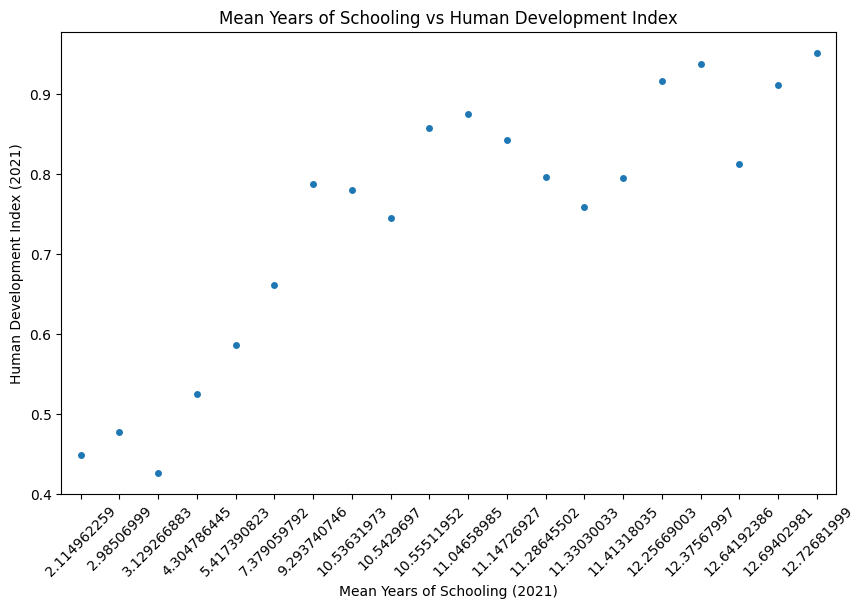

In [18]:
plt.figure(figsize=(10,6))

sns.stripplot(
    x='Mean Years of Schooling (2021)',
    y='Human Development Index (2021)',
    data=data1
)

plt.title("Mean Years of Schooling vs Human Development Index")
plt.xticks(rotation=45)

plt.show()

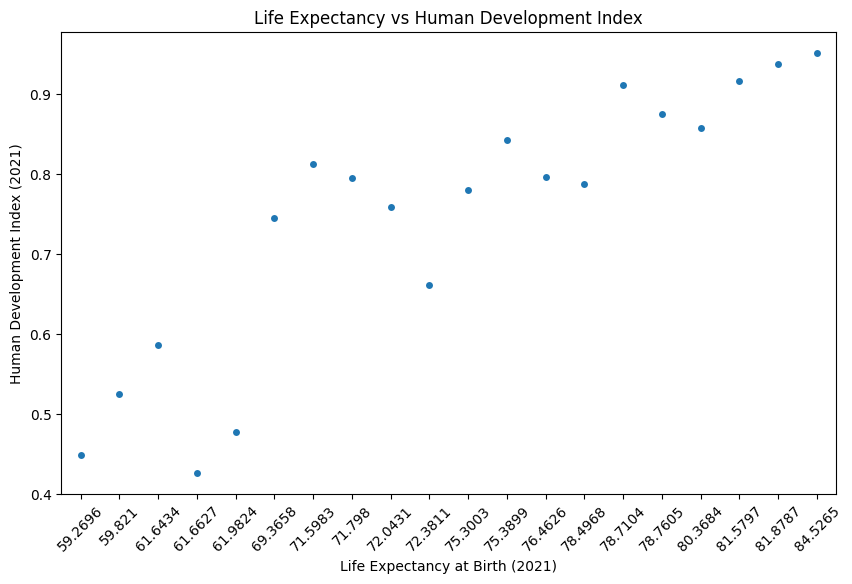

In [19]:
plt.figure(figsize=(10,6))

sns.stripplot(
    x='Life Expectancy at Birth (2021)',
    y='Human Development Index (2021)',
    data=data1
)

plt.title("Life Expectancy vs Human Development Index")
plt.xticks(rotation=45)

plt.show()

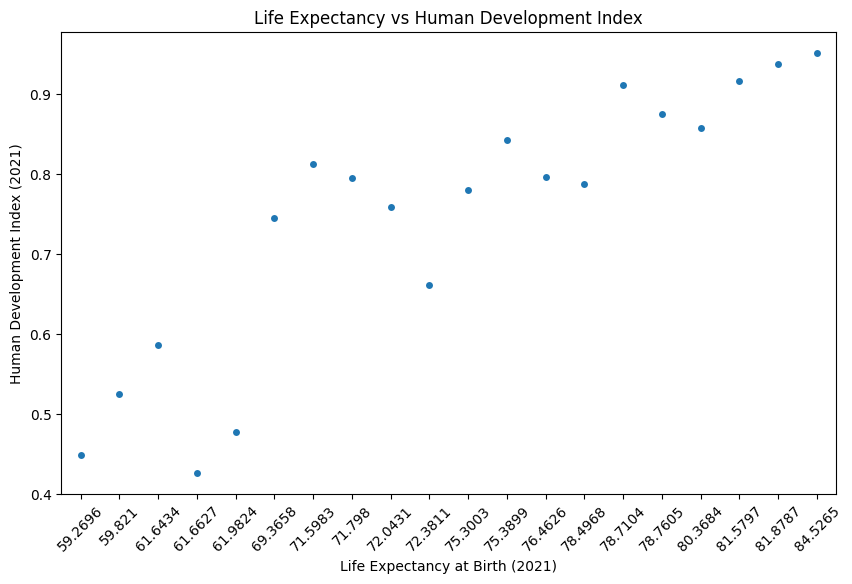

In [20]:
plt.figure(figsize=(10,6))

sns.stripplot(
    x='Life Expectancy at Birth (2021)',
    y='Human Development Index (2021)',
    data=data1
)

plt.title("Life Expectancy vs Human Development Index")
plt.xticks(rotation=45)

plt.show()

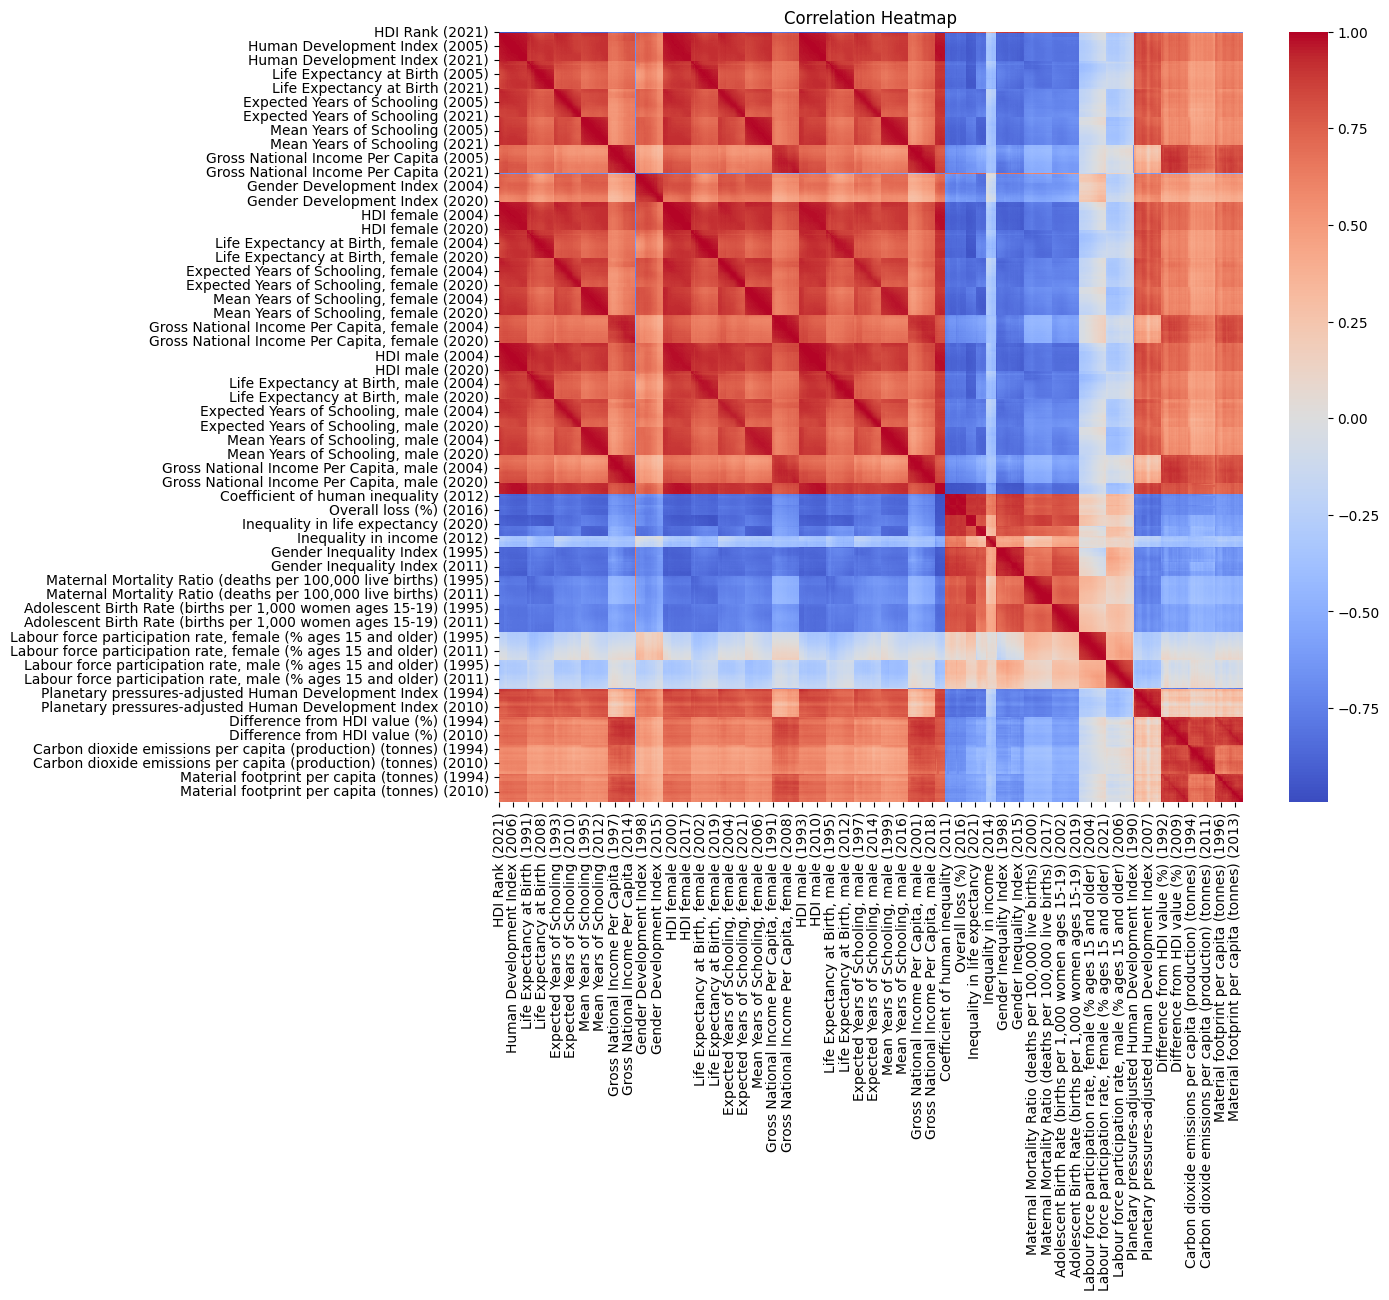

In [21]:
plt.figure(figsize=(12,10))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [22]:
df[['Human Development Index (2021)',
    'Life Expectancy at Birth (2021)',
    'Expected Years of Schooling (2021)',
    'Mean Years of Schooling (2021)',
    'Gross National Income Per Capita (2021)']].isnull().sum()

Human Development Index (2021)             4
Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         2
Mean Years of Schooling (2021)             4
Gross National Income Per Capita (2021)    2
dtype: int64

In [23]:
X = df[['Life Expectancy at Birth (2021)',
        'Expected Years of Schooling (2021)',
        'Mean Years of Schooling (2021)',
        'Gross National Income Per Capita (2021)']]

Y = df['Human Development Index (2021)']

In [24]:
X.head()

,Life Expectancy at Birth (2021),Expected Years of Schooling (2021),Mean Years of Schooling (2021),Gross National Income Per Capita (2021)
0,61.9824,10.263844,2.985070,1824.190915
1,61.6434,12.172100,5.417391,5465.617791
2,76.4626,14.448000,11.286455,14131.110390
3,80.3684,13.300239,10.555120,51166.626610
4,78.7104,15.717690,12.694030,62573.591810


In [25]:
Y.head()

0    0.478
1    0.586
2    0.796
3    0.858
4    0.911
Name: Human Development Index (2021), dtype: float64

In [26]:
X.isnull().sum()

Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         2
Mean Years of Schooling (2021)             4
Gross National Income Per Capita (2021)    2
dtype: int64

In [27]:
X = X.fillna(X.mean())


In [28]:
X.isnull().sum()

Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         0
Mean Years of Schooling (2021)             0
Gross National Income Per Capita (2021)    0
dtype: int64

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [30]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)

X_train: (156, 4)
X_test : (39, 4)
Y_train: (156,)
Y_test : (39,)


In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
model = LinearRegression()

In [33]:
Y.isnull().sum()

np.int64(4)

In [34]:
df = df.dropna(subset=['Human Development Index (2021)'])

In [35]:
X = df[['Life Expectancy at Birth (2021)',
        'Expected Years of Schooling (2021)',
        'Mean Years of Schooling (2021)',
        'Gross National Income Per Capita (2021)']]

Y = df['Human Development Index (2021)']

In [36]:
X = X.fillna(X.mean())

In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [38]:
model = LinearRegression()

model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
Y_pred = model.predict(X_test)

In [40]:
print(Y_pred)

[0.49934346 0.53987054 0.71530562 0.4931097  0.68042162 0.67111178
 0.90941976 0.7755583  0.95433843 0.42904406 0.87472271 0.43225764
 0.78960798 0.97161671 0.65816534 0.74547713 0.79337957 0.51182025
 0.39388825 0.89161716 0.97236295 0.79931717 0.53838309 0.52400236
 0.80847424 0.75719323 0.57810162 0.77387469 0.47930342 0.83222196
 0.73826953 0.91690117 0.84557668 0.7973612  0.73708989 0.58257105
 0.76385548 0.75167646 0.74571066]


In [41]:
print(Y_test.values)

[0.477 0.535 0.73  0.483 0.706 0.661 0.916 0.795 0.941 0.4   0.876 0.385
 0.812 0.947 0.639 0.727 0.802 0.5   0.394 0.896 0.962 0.79  0.596 0.481
 0.795 0.77  0.607 0.78  0.509 0.846 0.745 0.887 0.842 0.816 0.692 0.577
 0.767 0.751 0.707]


In [42]:
comparison = pd.DataFrame({
    'Actual HDI': Y_test.values,
    'Predicted HDI': Y_pred
})

comparison.head(10)

,Actual HDI,Predicted HDI
0,0.477,0.499343
1,0.535,0.539871
2,0.730,0.715306
3,0.483,0.493110
4,0.706,0.680422
5,0.661,0.671112
6,0.916,0.909420
7,0.795,0.775558
8,0.941,0.954338
9,0.400,0.429044


In [43]:
score = r2_score(Y_test, Y_pred)

print("R² Score:", score)

R² Score: 0.9808147179258669


In [44]:
import pickle

with open("HDI.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [45]:
import pickle

with open("HDI.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
